# Prithvi WxC Downscaling with CORDEX Data: Model Inference

This notebook walks through running inference with a fine-tuned Prithvi downscaling model on CORDEX NZ data.

To replicate the results show in this notebook please download the required files from CORDEX-ML Bench (https://zenodo.org/records/17517423) repository

You need `git lfs` installed to download large files

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
from pathlib import Path
REPO_ROOT = Path("/mnt/data2/kyo/granite-wxc").resolve()
os.chdir("/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML")
print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


In [2]:
# ===================== USER PARAMETERS (EDIT ME) =====================
from pathlib import Path
from nz_params import UserParams, validate_paths

REPO_ROOT = Path("/mnt/data2/kyo/granite-wxc").resolve()
PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
DATASET_ROOT = REPO_ROOT / "granite-geospatial-wxc-downscaling/CORDEX/NZ_domain"

TRAIN_SPLIT = "train/ESD_pseudo_reality"
TEST_SPLIT = "test/historical_perfect"
PREDICTOR_FILE = "ACCESS-CM2_1961-1980_regridded.nc"
TARGET_FILE = "pr_tasmax_ACCESS-CM2_1961-1980.nc"

TRAIN_TARGETS = [DATASET_ROOT / TRAIN_SPLIT / "target" / TARGET_FILE]
TEST_PREDICTORS = sorted((DATASET_ROOT / TEST_SPLIT / "predictors").glob('*.nc'))

FINETUNE_RUN_NAME = None  # e.g., 'nz_debug_run'

P = UserParams(
    repo_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    runs_root=PROJECT_DIR / "runs/nz_finetune",
    config_path=PROJECT_DIR / "cordex_config_small.yaml",
    inference_run_name=FINETUNE_RUN_NAME,
    inference_output_root=PROJECT_DIR / "runs/nz_finetune/predictions",
    inference_predictor_root=DATASET_ROOT / TEST_SPLIT / "predictors",
    # NOTE: The notebook explicitly overrides config.data.test_* paths from the YAML.
    # Update these for each inference dataset; they take precedence over YAML defaults.
    test_predictor_paths=TEST_PREDICTORS,
    test_target_paths=TRAIN_TARGETS,
    checkpoint_path=None,
    preferred_checkpoint="best",
    device_target="cuda",
    num_workers=2,
)

validate_paths(P, require_inference=True)
print(P.summary())


Repo root: /mnt/data2/kyo/granite-wxc
Project dir: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML
Runs root: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune
Config: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/cordex_config_small.yaml
Run name override: <auto>
Inference run override: <latest>
Preferred checkpoint: best
Device target: cuda
Batch size override: <config>
Dataloader workers override: 2
Train predictors: 0 file(s)
Validation predictors: 0 file(s)
Test predictors: 1 file(s)
Checkpoint path override: <auto>
Inference output root: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/predictions
Inference predictor root: /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/CORDEX/NZ_domain/test/historical_perfect/predictors


In [3]:
from pathlib import Path
import os

os.chdir(P.repo_root)
print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /mnt/data2/kyo/granite-wxc


In [4]:
import os

os.chdir(P.project_dir)
print(f"Project directory set to: {os.getcwd()}")

Project directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


If your current directory is not `granite-wxc/`, change it using the following command:

```bash
%cd <local>/granite-wxc/
```

Replace `<local>` with the appropriate path prefix 

In [5]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [6]:
!pip install -q h5netcdf matplotlib wget pyyaml xarray scipy torch tqdm pysteps cartopy

In [7]:
import logging
import warnings
logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from contextlib import nullcontext
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

from cordex_inference import CordexWrappedDataset, build_inference_dataset
from granitewxc.utils.config import get_config
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model


/mnt/data2/kyo/mamba/envs/Prithvi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configure the backends, PyTorch states, and random seeds to standardize the RNG for random crops in this example

In [9]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
    torch.cuda.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [10]:
target = (getattr(P, 'device_target', 'auto') or 'auto').lower()
if target == 'cuda':
    if not torch.cuda.is_available():
        raise RuntimeError("device_target is 'cuda' but no CUDA device is available.")
    device = torch.device('cuda')
elif target == 'cpu':
    device = torch.device('cpu')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [11]:
import os
from pathlib import Path

from run_utils import (
    assert_no_eccc_reference,
    load_run_manifest,
)
from nz_params import resolve_existing_run_dir, resolve_checkpoint, export_params

RUN_NAME, run_dir = resolve_existing_run_dir(P)
manifest = load_run_manifest(run_dir)
resolved_config_path = Path(manifest['config_snapshot']).resolve()
os.chdir(P.project_dir)
config = get_config(str(resolved_config_path))
assert_no_eccc_reference(resolved_config_path)

if P.num_workers is not None:
    config.dl_num_workers = int(P.num_workers)
if P.batch_size is not None:
    config.batch_size = int(P.batch_size)
config.device_target = getattr(P, 'device_target', config.device_target)

checkpoint_path = resolve_checkpoint(P, run_dir)
assert_no_eccc_reference(checkpoint_path)

output_root = Path(P.inference_output_root or (run_dir / 'predictions'))
OUTPUT_DIR = output_root / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

params_json = export_params(
    P,
    OUTPUT_DIR / 'inference_params.json',
    extra={'run_name': RUN_NAME, 'checkpoint': str(checkpoint_path)},
)

print(f"Using fine-tune run '{RUN_NAME}' located at {run_dir}")
print(f"Resolved checkpoint: {checkpoint_path}")
print(f"Inference artifacts will be written to {OUTPUT_DIR}")
print(f"Saved parameter snapshot to {params_json}")

CHECKPOINT_PATH = checkpoint_path

Using fine-tune run 'NZ_ESD_pseudo-reality' located at /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/NZ_ESD_pseudo-reality
Resolved checkpoint: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/NZ_ESD_pseudo-reality/checkpoints/best.ckpt
Inference artifacts will be written to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/predictions/NZ_ESD_pseudo-reality
Saved parameter snapshot to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/predictions/NZ_ESD_pseudo-reality/inference_params.json


## Configuration File

The model is configured using `YAML` files.

In these files, you specify:
- Paths to the input data  
- Locations of the pretrained weights  

To ensure compatibility with the provided weights during inference, keep the model configuration consistent with the original definitions 

In [12]:
from pathlib import Path

def _resolve_inputs(values):
    return [str(Path(p).resolve()) for p in values]

test_predictor_paths = _resolve_inputs(P.test_predictor_paths) if P.test_predictor_paths else []
if not test_predictor_paths and P.inference_predictor_root:
    test_predictor_paths = [str(path.resolve()) for path in Path(P.inference_predictor_root).glob('*.nc')]

if not test_predictor_paths:
    raise FileNotFoundError('No inference predictor files configured in USER PARAMETERS.')

config.data.test_predictor_paths = test_predictor_paths
if P.test_target_paths:
    config.data.test_target_paths = _resolve_inputs(P.test_target_paths)

root_dir = Path(test_predictor_paths[0]).parent
print(f"Using perfect predictors from {root_dir} ({len(test_predictor_paths)} files)")

Using perfect predictors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/CORDEX/NZ_domain/test/historical_perfect/predictors (1 files)


In [13]:
preproc_cache = Path(manifest["preproc_dir"]).resolve()
print(f"Preprocessed predictor cache (shared with fine-tune run): {preproc_cache}")


Preprocessed predictor cache (shared with fine-tune run): /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/NZ_ESD_pseudo-reality/preproc


## Dataloader 

We reuse the same regridded CORDEX sample for testing to showcase the end-to-end pipeline.

In [14]:
def build_dataloader(predictor_paths, target_paths):
    base_dataset = build_inference_dataset(config, predictor_paths, target_paths)
    dataset = CordexWrappedDataset(base_dataset)
    batch_size = getattr(config, 'batch_size', 1)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=config.dl_num_workers,
        pin_memory=(device.type == 'cuda'),
    )


In [15]:
test_dl = build_dataloader(
    config.data.test_predictor_paths, config.data.test_target_paths
)

In [16]:
base_dataset = test_dl.dataset.base
inference_target_vars = list(base_dataset.target_vars)
print(f"Inference target variables: {inference_target_vars}")
if set(inference_target_vars) != {"pr", "tasmax"}:
    raise ValueError(
        "Inference dataloader must expose both 'pr' and 'tasmax' targets; update the config/output_vars list."
    )
print(f"Total inference samples: {len(base_dataset)} (time steps across {len(base_dataset.predictor_paths)} predictor file(s))")


Inference target variables: ['pr', 'tasmax']
Total inference samples: 7300 (time steps across 1 predictor file(s))


## Model Initialization

We provide **2** different model architectures `UNET-like` and `CONV` 

Both architectures include:  
1. **Patch Embedding**: Extracts shallow features from the input data  
2. **Feature Extraction**: Utilizes the Prithvi backbone to extract deeper features  

The key difference is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we use the **UNET-like** version

To switch to the **CONV** model, update the configuration file accordingly and use `get_finetune_model(config)`

In [17]:
model = get_finetune_model_UNET(config)

Creating the model.
--> model has 254,372,744 params.


In [18]:
from pathlib import Path

assert_no_eccc_reference(CHECKPOINT_PATH)
checkpoint = torch.load(str(CHECKPOINT_PATH), map_location='cpu', weights_only=False)
state_dict = checkpoint['model'] if isinstance(checkpoint, dict) and 'model' in checkpoint else checkpoint
model_state = model.state_dict()
weights_have_module_prefix = all(key.startswith('module.') for key in state_dict.keys())
model_expects_module_prefix = all(key.startswith('module.') for key in model_state.keys())

if model_expects_module_prefix and not weights_have_module_prefix:
    state_dict = state_dict.__class__((('module.' + key), value) for key, value in state_dict.items())
elif weights_have_module_prefix and not model_expects_module_prefix:
    prefix_len = len('module.')
    state_dict = state_dict.__class__((key[prefix_len:], value) for key, value in state_dict.items())

scaler_key_parts = (
    'input_scalers_',
    'output_scalers_',
    'static_input_scalers_',
    'static_output_scalers_',
)
state_dict = state_dict.__class__(
    (key, value)
    for key, value in state_dict.items()
    if not any(part in key for part in scaler_key_parts)
)
incompatible = model.load_state_dict(state_dict, strict=False)
missing = [
    key
    for key in incompatible.missing_keys
    if not any(part in key for part in scaler_key_parts)
]
if missing or incompatible.unexpected_keys:
    raise RuntimeError(
        'Checkpoint/model mismatch after filtering scaler tensors. ' 
        f'missing={missing[:8]}, unexpected={incompatible.unexpected_keys[:8]}'
    )
model.to(device)

skip_offload_devices = []
if device.type == 'cuda' and torch.cuda.device_count() > 1:
    skip_offload_devices = [torch.device(f'cuda:{idx}') for idx in range(1, torch.cuda.device_count())]
    if skip_offload_devices and hasattr(model, 'set_skip_activation_devices'):
        model.set_skip_activation_devices(skip_offload_devices)
        print(f"--> Offloading skip activations to GPUs: {skip_offload_devices}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
first_tensor = next(iter(model.state_dict().values()))
mean_val = first_tensor.float().mean().item()
std_val = first_tensor.float().std().item()

print(f"Loaded fine-tuned weights from {CHECKPOINT_PATH}")
print(f"Trainable parameter count: {total_params:,}")
print(f"First state_dict tensor stats -> mean: {mean_val:.6f}, std: {std_val:.6f}")

--> Offloading skip activations to GPUs: [device(type='cuda', index=1), device(type='cuda', index=2), device(type='cuda', index=3)]
Loaded fine-tuned weights from /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/NZ_ESD_pseudo-reality/checkpoints/best.ckpt
Trainable parameter count: 254,372,744
First state_dict tensor stats -> mean: 728.312622, std: 1580.791016


We can now load the pretrained weights

In [19]:
# Checkpoint loading handled earlier with CHECKPOINT_PATH.

### Inference

The model is now ready for inference. We run inference for one batch (batch_size=1).

In [20]:
with torch.no_grad():
    model.eval()
    
    batch = next(iter(test_dl))
    batch = {k: v.to(device) for k, v in batch.items()}
    autocast_enabled = device.type == "cuda"
    autocast_dtype = torch.bfloat16 if (autocast_enabled and torch.cuda.is_bf16_supported()) else torch.float16
    autocast_ctx = torch.cuda.amp.autocast(dtype=autocast_dtype, enabled=autocast_enabled) if autocast_enabled else nullcontext()
    
    with autocast_ctx:
        out = model(batch)

    inputs = batch['x']
    targets = batch['y']
    outputs = out

In [21]:
inputs.shape, targets.shape, outputs.shape

(torch.Size([1, 15, 128, 128]),
 torch.Size([1, 2, 128, 128]),
 torch.Size([1, 2, 128, 128]))

inputs.shape, targets.shape, outputs.shape

In [22]:
### Plotting

#We visualise one of the output channels to inspect the prediction quality.

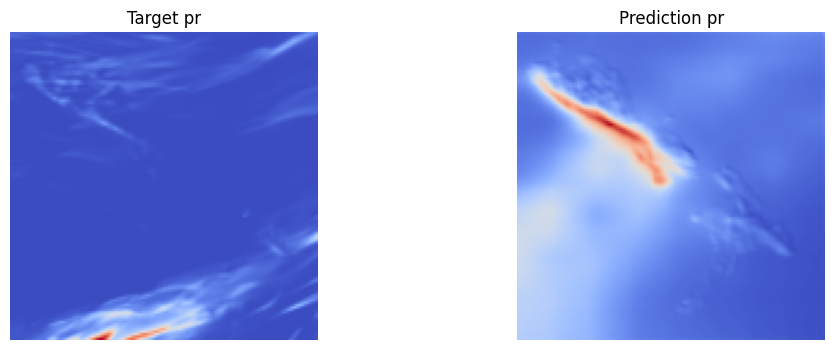

In [23]:
var_names = list(config.data.output_vars)
var_idx = 0  # pr
sample_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(targets[sample_idx, var_idx].cpu(), cmap='coolwarm')
axes[0].set_title(f'Target {var_names[var_idx]}')
axes[0].axis("off")
axes[1].imshow(outputs[sample_idx, var_idx].cpu(), cmap='coolwarm')
axes[1].set_title(f'Prediction {var_names[var_idx]}')
axes[1].axis("off")
plt.show()

In [24]:
prediction_output_path = OUTPUT_DIR / f"{RUN_NAME}_predictions.nc"
prediction_output_path.parent.mkdir(parents=True, exist_ok=True)

base_dataset = test_dl.dataset.base
time_dim = base_dataset.time_dim or 'time'
lat_dim, lon_dim = base_dataset.output_spatial_dims
lat_name = base_dataset.fine_lat_name
lon_name = base_dataset.fine_lon_name
target_vars = list(base_dataset.target_vars)
predictor_paths = list(base_dataset.predictor_paths)
target_template_paths = list(base_dataset.target_paths)

def _run_full_inference(dataloader, model, device):
    predictions = []
    autocast_enabled = device.type == 'cuda'
    autocast_dtype = (
        torch.bfloat16 if (autocast_enabled and torch.cuda.is_bf16_supported()) else torch.float16
    )

    def autocast_context():
        return (
            torch.cuda.amp.autocast(dtype=autocast_dtype, enabled=autocast_enabled)
            if autocast_enabled
            else nullcontext()
        )

    with torch.no_grad():
        model.eval()
        for batch in tqdm(dataloader, desc='Running inference', leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            with autocast_context():
                out = model(batch)
            predictions.append(out.detach().cpu())
    return torch.cat(predictions, dim=0)


def _concat_time_coordinate(paths, time_key):
    arrays = []
    attrs = None
    encoding = None
    for path in paths:
        with xr.open_dataset(path, engine='netcdf4') as ds:
            if time_key not in ds.coords and time_key not in ds.data_vars:
                raise KeyError(f"Time dimension '{time_key}' missing in {path}")
            da = ds[time_key]
            arrays.append(da)
            if attrs is None:
                attrs = dict(da.attrs)
            if encoding is None and hasattr(da, 'encoding'):
                encoding = dict(da.encoding)
    combined = xr.concat(arrays, dim=time_key)
    if attrs:
        combined.attrs.update(attrs)
    if encoding:
        combined.encoding.update(encoding)
    return combined.load()


full_outputs = _run_full_inference(test_dl, model, device)
outputs_np = full_outputs.numpy()
if outputs_np.shape[1] != len(target_vars):
    raise ValueError(
        f"Model produced {outputs_np.shape[1]} channels but target_vars expects {len(target_vars)}"
    )

predictor_time_coord = _concat_time_coordinate(predictor_paths, time_dim)
if outputs_np.shape[0] != predictor_time_coord.sizes[time_dim]:
    raise ValueError(
        f"Prediction time dimension {outputs_np.shape[0]} does not match predictor timestamps {predictor_time_coord.sizes[time_dim]}"
    )

start_time = predictor_time_coord.values[0]
end_time = predictor_time_coord.values[-1]
print(
    f"Predictor-driven time axis spans {start_time} to {end_time} ({predictor_time_coord.sizes[time_dim]} steps)."
)

if not target_template_paths:
    raise FileNotFoundError('Target template paths missing; ensure config.data.test_target_paths is set')

with xr.open_dataset(target_template_paths[0], engine='h5netcdf') as template_ds:
    template_attrs = dict(template_ds.attrs)
    target_attrs = {
        name: dict(template_ds[name].attrs)
        for name in target_vars
        if name in template_ds.data_vars
    }
    lat_coord = template_ds[lat_name].load()
    lon_coord = template_ds[lon_name].load()

Predictor-driven time axis spans 1981-01-01T00:00:00.000000000 to 2000-12-31T00:00:00.000000000 (7300 steps).


In [25]:
coords = {
    time_dim: predictor_time_coord,
    lat_dim: lat_coord,
    lon_dim: lon_coord,
}

prediction_ds = xr.Dataset(coords=coords)
for idx, name in enumerate(target_vars):
    prediction_ds[name] = xr.DataArray(
        outputs_np[:, idx],
        dims=(time_dim, lat_dim, lon_dim),
        coords=coords,
        attrs=target_attrs.get(name, {}),
    )

prediction_ds.attrs.update(template_attrs)
prediction_ds.to_netcdf(prediction_output_path, engine="h5netcdf")
print(
    f"Saved predictions to {prediction_output_path} with time range {predictor_time_coord.values[0]} to {predictor_time_coord.values[-1]}"
)


Saved predictions to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/predictions/NZ_ESD_pseudo-reality/NZ_ESD_pseudo-reality_predictions.nc with time range 1981-01-01T00:00:00.000000000 to 2000-12-31T00:00:00.000000000


In [26]:
import pickle

pickle_path = OUTPUT_DIR / f"{RUN_NAME}_predictions.pkl"
with open(pickle_path, 'wb') as handle:
    pickle.dump(outputs_np, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved raw predictions array to {pickle_path}")

Saved raw predictions array to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs/nz_finetune/predictions/NZ_ESD_pseudo-reality/NZ_ESD_pseudo-reality_predictions.pkl
